In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
new_dir = "/content/drive/My Drive/566project"
os.chdir(new_dir)
current_dir = os.getcwd()
print(f"new directory: {current_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
new directory: /content/drive/My Drive/566project


In [ ]:
!pip install scapy pandas

###Why AutoEncoder for Intelligent Caching?
learn the model of DNS:
  * high similarity: it's the popular search
  * low similarity: it might be uncommon search/bad search

In [ ]:
import ipaddress
import numpy as np
from scapy.all import RawPcapReader, Ether, IP, IPv6, UDP, TCP, DNS

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict

In [ ]:
# === 系统流量判断函数 ===
# 有待继续添加规则
def is_system_qname(qname):
    system_keywords = [
        "arpa",             # ip6.arpa, in-addr.arpa
        "bind",             # hostname.bind
        "_dns-sd._udp",     # DNS-SD 服务发现
        ".gtld-servers",    # 根域服务器
        "ec2.internal",     # AWS
        "cluster.local",    # K8s
        "azure-dns",        # Azure
    ]
    return any(keyword in qname.lower() for keyword in system_keywords)

In [ ]:
# === 域名合法性判断函数 ===
def is_valid_qname(qname):
    if not qname:
        return False
    qname = qname.lower()

    invalid_tlds = {"com", "net", "org", "cn", "edu", "gov", "mil"}
    if qname in invalid_tlds:
        return False

    if '.' not in qname:
        return False

    reserved = ["localhost", "local", "invalid", "test"]
    if any(r in qname for r in reserved):
        return False

    return True

In [ ]:
# === 特征提取函数 ===
def extract_features_from_pcap(pcap_file, max_count=10000):
    features_all = []
    features_non_system = []
    qnames = []
    is_system_flags = []
    sample_indices = []  # 保存样本在循环中的索引（或顺序号）
    domain_counter = defaultdict(int)

    reader = RawPcapReader(pcap_file)
    count = 0

    for pkt_data, pkt_metadata in reader:
        if count >= max_count:
            break

        try:
            eth = Ether(pkt_data)
        except:
            continue

        if eth.haslayer(IP):
            net_pkt = eth[IP]
        elif eth.haslayer(IPv6):
            net_pkt = eth[IPv6]
        else:
            continue

        if not net_pkt.haslayer(UDP) or not net_pkt.haslayer(DNS):
            continue

        dns = net_pkt[DNS]

        if dns.qr != 0 or dns.qdcount == 0:
            continue

        try:
            qname_raw = dns.qd[0].qname.decode(errors="ignore").strip(".")
        except:
            continue

        if not is_valid_qname(qname_raw):
            continue

        qname = qname_raw
        domain_counter[qname] += 1
        qnames.append(qname)
        sample_indices.append(count)

        try:
            src_ip_val = int(ipaddress.ip_address(net_pkt.src))
            dst_ip_val = int(ipaddress.ip_address(net_pkt.dst))
        except:
            src_ip_val = 0
            dst_ip_val = 0

        feature = [
            len(net_pkt),                             # 包大小
            getattr(net_pkt, 'time', 0),              # 时间戳
            src_ip_val,
            dst_ip_val,
            getattr(net_pkt, 'proto', 0),             # 协议
            getattr(net_pkt, 'sport', -1),            # 源端口
            getattr(net_pkt, 'dport', -1),            # 目的端口
            getattr(net_pkt, 'ttl', 64),              # TTL
            getattr(net_pkt, 'len', 0),               # IP包长度
            getattr(net_pkt, 'id', 0),                # 标识符
            getattr(net_pkt, 'frag_offset', 0),       # 分片偏移
        ]

        features_all.append(feature)
        is_system = int(is_system_qname(qname))  # 0 = 非系统流量, 1 = 系统流量
        is_system_flags.append(is_system)

        if not is_system:
            features_non_system.append(feature)

        count += 1

    return (
        np.array(features_all),
        np.array(features_non_system),
        qnames,
        np.array(is_system_flags),
        domain_counter,
        sample_indices
    )

In [ ]:
# === 载入数据 ===
pcap_file = "20210118-000020-00460916.mia.pcap"
features_all, features_train, qnames, is_system_flags, domain_counter, sample_indices = extract_features_from_pcap(pcap_file, 30000)

print(f"Total DNS Queries: {len(features_all)}")
print(f"Used for Training (non-system): {len(features_train)}")

Total DNS Queries: 30000
Used for Training (non-system): 24081


In [ ]:
# === 标准化训练数据（非系统流量）===
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)

In [ ]:
# === 构建 Autoencoder 模型 ===
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
# === 数据划分与准备 ===
torch.manual_seed(42)
np.random.seed(42)

features_tensor = torch.tensor(features_train, dtype=torch.float32)
total = len(features_tensor)
train_end = int(0.625 * total)
val_end = int(0.875 * total)

train_data = features_tensor[:train_end]
val_data = features_tensor[train_end:val_end]
test_data = features_tensor[val_end:]

batch_size = 128
train_loader = DataLoader(TensorDataset(train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_data), batch_size=batch_size, shuffle=False)

In [ ]:
# === 模型训练 ===
model = Autoencoder(input_dim=features_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss, val_loss = [], []
best_val_loss = float('inf')
patience, no_improve = 20, 0
num_epochs = 300

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss.append(epoch_train_loss / len(train_loader))

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            output = model(batch)
            loss = criterion(output, batch)
            epoch_val_loss += loss.item()
    val_loss.append(epoch_val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss[-1]:.6f} | Val Loss: {val_loss[-1]:.6f}")

    if val_loss[-1] < best_val_loss - 1e-4:
        best_val_loss = val_loss[-1]
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

Epoch 1/300 | Train Loss: 0.710252 | Val Loss: 0.590600
Epoch 2/300 | Train Loss: 0.318932 | Val Loss: 0.370478
Epoch 3/300 | Train Loss: 0.212489 | Val Loss: 0.310180
Epoch 4/300 | Train Loss: 0.159842 | Val Loss: 0.296182
Epoch 5/300 | Train Loss: 0.131562 | Val Loss: 0.262364
Epoch 6/300 | Train Loss: 0.119851 | Val Loss: 0.257062
Epoch 7/300 | Train Loss: 0.113041 | Val Loss: 0.259550
Epoch 8/300 | Train Loss: 0.108388 | Val Loss: 0.245325
Epoch 9/300 | Train Loss: 0.104195 | Val Loss: 0.247579
Epoch 10/300 | Train Loss: 0.099453 | Val Loss: 0.231928
Epoch 11/300 | Train Loss: 0.095170 | Val Loss: 0.229258
Epoch 12/300 | Train Loss: 0.087376 | Val Loss: 0.225613
Epoch 13/300 | Train Loss: 0.080253 | Val Loss: 0.234722
Epoch 14/300 | Train Loss: 0.075759 | Val Loss: 0.210824
Epoch 15/300 | Train Loss: 0.070156 | Val Loss: 0.197295
Epoch 16/300 | Train Loss: 0.068319 | Val Loss: 0.192723
Epoch 17/300 | Train Loss: 0.065745 | Val Loss: 0.193182
Epoch 18/300 | Train Loss: 0.062855 | Va

In [ ]:
# === 测试集评估 ===
model.eval()
test_loss = 0.0
with torch.no_grad():
    for (batch,) in test_loader:
        output = model(batch)
        loss = criterion(output, batch)
        test_loss += loss.item()
avg_test_loss = test_loss / len(test_loader)
print(f"\nTest Loss: {avg_test_loss:.6f}")


Test Loss: 0.161592


graph of loss

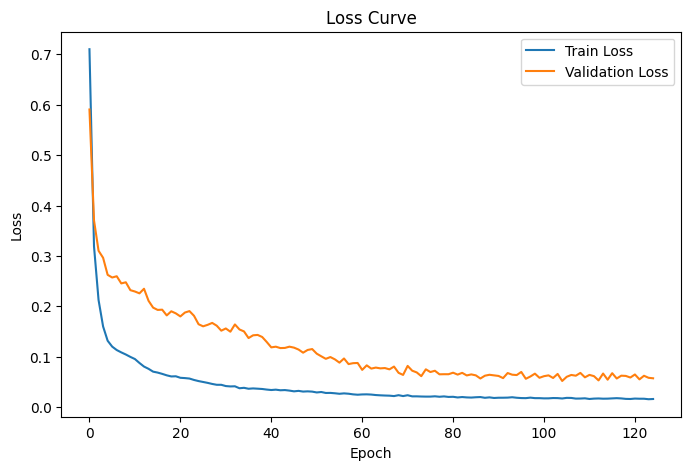

In [ ]:
# === 可视化 Loss 曲线 ===
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

plot_loss(train_loss, val_loss)

In [ ]:
import joblib

# 保存 PyTorch 模型
torch.save(model.state_dict(), "dns_autoencoder.pt")
print("Autoencoder model saved as dns_autoencoder.pt")

# 保存 scaler
joblib.dump(scaler, "dns_scaler.pkl")
print("StandardScaler saved as dns_scaler.pkl")


Autoencoder model saved as dns_autoencoder.pt
StandardScaler saved as dns_scaler.pkl


In [ ]:
# ----------------------------
# 以下为排查代码（异常样本定位）：
# 计算每个样本的重构误差，然后根据阈值或排名来查找对应的 qname 和原始特征
# 注意：这里以训练数据（非系统流量）为例，features_train 与 qnames 对应的是非系统流量部分，
#       需要确保 qnames 的顺序和 features_train 的顺序一致（本例中是这样，因为我们只用了非系统流量）

# 先将所有样本转为张量
features_tensor_full = torch.tensor(features_train, dtype=torch.float32)

model.eval()
with torch.no_grad():
    reconstructed = model(features_tensor_full)
    # 计算每个样本的重构误差（例如 MSE）
    reconstruction_errors = ((features_tensor_full - reconstructed)**2).mean(dim=1).cpu().numpy()

# 假设我们想查看重构误差最高的前 10 个异常样本
top_k = 10
sorted_indices = np.argsort(-reconstruction_errors)  # 从大到小排序
outlier_indices = sorted_indices[:top_k]

print("\n=== 异常样本排查 ===")
for idx in outlier_indices:
    print(f"样本索引: {idx} (原始序号: {sample_indices[idx]})")
    print(f"  重构误差: {reconstruction_errors[idx]:.6f}")
    print(f"  域名: {qnames[idx]}")
    print(f"  特征值（归一化后）: {features_train[idx]}")
    print("---------------")

# 你可以根据需要调整 top_k 或设定一个重构误差阈值来筛选样本：
threshold = 0.3  # 例如设定一个阈值
threshold_indices = np.where(reconstruction_errors > threshold)[0]
print(f"\n重构误差大于 {threshold} 的样本数: {len(threshold_indices)}")
for idx in threshold_indices:
    print(f"样本索引: {idx} (原始序号: {sample_indices[idx]}), 重构误差: {reconstruction_errors[idx]:.6f}, 域名: {qnames[idx]}")


=== 异常样本排查 ===
样本索引: 7743 (原始序号: 7743)
  重构误差: 1.050892
  域名: cliente-marketplacemagazine.tk.sa-east-1.compute.internal
  特征值（归一化后）: [ 0.08027666 -0.60400563 15.28068936  2.13274882 -2.13274882 -1.81654897
  0.         -0.45491189 -1.02289209  1.2170855   0.        ]
---------------
样本索引: 8858 (原始序号: 8858)
  重构误差: 0.948505
  域名: b.root-servers.net
  特征值（归一化后）: [ 0.08027666 -0.45071149 15.28068936  2.13274882 -2.13274882 -1.69462297
  0.         -0.45491189 -1.02289209  0.56575612  0.        ]
---------------
样本索引: 10549 (原始序号: 10549)
  重构误差: 0.609980
  域名: ns1.c-msedge.net
  特征值（归一化后）: [ 0.46998734 -0.20602344 15.31004838  2.13274882 -2.13274882  0.53913954
  0.         -0.45491189 -0.65428357  1.72621955  0.        ]
---------------
样本索引: 23770 (原始序号: 23770)
  重构误差: 0.498148
  域名: nsa2.worldsecuresystems.com
  特征值（归一化后）: [ 0.04484841  1.66854875 -0.42854308 -0.46887847  0.46887847  1.40129055
  0.          2.0828179   0.28399267 -1.66704227  0.        ]
---------------
样本索引: 23788 (原